# HW10-11: компьютерное зрение в PyTorch
Обязательная часть: классификация (C1-C4) + segmentation track (V1-V2).

## Импорты, seed и устройство
В этом блоке загружаются библиотеки, фиксируется seed и определяется device.

In [1]:
import torch, torchvision, numpy as np
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)
print('cuda available:', torch.cuda.is_available())

torch 2.11.0+cpu
torchvision 0.26.0+cpu
cuda available: False


## Основной пайплайн
Ниже реализованы функции и запуск экспериментов:
- `train_one_epoch`, `evaluate`
- C1-C4 на `Flowers102`
- V1-V2 на `OxfordIIITPet` с pretrained `DeepLabV3_ResNet50`
- сохранение всех обязательных артефактов в `artifacts/`.

In [2]:
import copy
import json
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


SEED = 42
BATCH_SIZE_CNN = 64
BATCH_SIZE_RESNET = 32
NUM_WORKERS = 0
CLASSIFICATION_EPOCHS = {"C1": 4, "C2": 4, "C3": 2, "C4": 2}
SEGMENTATION_MAX_SAMPLES = 80


@dataclass
class ExperimentOutput:
    model: nn.Module
    best_state: dict
    history: dict
    best_val_accuracy: float
    best_epoch: int
    model_summary: str
    optimizer_name: str
    lr: float
    train_transform_name: str
    eval_transform_name: str


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_loader(dataset, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        running_total += targets.size(0)

    return running_loss / running_total, running_correct / running_total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * targets.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        running_total += targets.size(0)

    return running_loss / running_total, running_correct / running_total


class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def build_resnet18(num_classes: int, mode: str) -> nn.Module:
    # Explicitly load ImageNet pretrained weights for transfer learning (C3/C4).
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    except AttributeError:
        # Fallback for older torchvision API.
        model = models.resnet18(pretrained=True)

    for p in model.parameters():
        p.requires_grad = False

    if mode == "partial":
        for p in model.layer4.parameters():
            p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    for p in model.fc.parameters():
        p.requires_grad = True
    return model


def run_classification_experiment(
    experiment_id: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
    model_summary: str,
    train_transform_name: str,
    eval_transform_name: str,
) -> ExperimentOutput:
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)
    optimizer_name = "Adam"

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_accuracy = -1.0
    best_epoch = 1

    print(f"[{experiment_id}] start training: epochs={epochs}, lr={lr}")
    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"[{experiment_id}] epoch={epoch:02d} "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
            f"train_acc={train_accuracy:.4f} val_acc={val_accuracy:.4f}"
        )

    model.load_state_dict(best_state)
    return ExperimentOutput(
        model=model,
        best_state=best_state,
        history=history,
        best_val_accuracy=best_val_accuracy,
        best_epoch=best_epoch,
        model_summary=model_summary,
        optimizer_name=optimizer_name,
        lr=lr,
        train_transform_name=train_transform_name,
        eval_transform_name=eval_transform_name,
    )


def denormalize_image(img_tensor, mean, std):
    out = img_tensor.detach().cpu().clone()
    for channel, (m, s) in enumerate(zip(mean, std)):
        out[channel] = out[channel] * s + m
    return out.clamp(0, 1)


def save_augmentations_preview(fig_path: Path, raw_dataset, aug_preview_transform):
    image, _ = raw_dataset[0]
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(1, 6):
        axes[i].imshow(aug_preview_transform(image))
        axes[i].set_title(f"Aug {i}")
        axes[i].axis("off")

    fig.suptitle("Flowers102 augmentations preview")
    fig.tight_layout()
    fig.savefig(fig_path, dpi=160)
    plt.close(fig)


def save_classification_curves(fig_path: Path, history: dict, experiment_id: str):
    epochs = history["epoch"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("CrossEntropyLoss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_accuracy"], marker="o", label="train")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.suptitle(f"Classification curves for {experiment_id}")
    fig.tight_layout()
    fig.savefig(fig_path, dpi=160)
    plt.close(fig)


def save_classification_compare(fig_path: Path, scores: dict):
    exp_ids = list(scores.keys())
    values = [scores[e] for e in exp_ids]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(exp_ids, values, color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"])
    ax.set_ylim(0.0, max(values) * 1.2 if values else 1.0)
    ax.set_title("Best val accuracy by experiment")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Best val accuracy")
    for x, y in zip(exp_ids, values):
        ax.text(x, y + 0.003, f"{y:.3f}", ha="center", va="bottom")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(fig_path, dpi=160)
    plt.close(fig)


@torch.no_grad()
def run_segmentation_mode(model, dataset, device, threshold, max_samples, cat_idx=8, dog_idx=12):
    model.eval()

    total_tp = 0
    total_fp = 0
    total_fn = 0
    ious = []
    examples = []

    sample_count = min(max_samples, len(dataset))
    for idx in range(sample_count):
        image_tensor, gt_mask = dataset[idx]

        logits = model(image_tensor.unsqueeze(0).to(device))["out"][0].cpu()
        probs = torch.softmax(logits, dim=0)
        fg_prob = probs[cat_idx] + probs[dog_idx]
        pred_fg = fg_prob >= threshold

        gt_fg = gt_mask == 1
        valid_mask = gt_mask != 3

        tp = int(((pred_fg & gt_fg) & valid_mask).sum().item())
        fp = int(((pred_fg & (~gt_fg)) & valid_mask).sum().item())
        fn = int((((~pred_fg) & gt_fg) & valid_mask).sum().item())
        inter = tp
        union = int((((pred_fg | gt_fg) & valid_mask)).sum().item())

        total_tp += tp
        total_fp += fp
        total_fn += fn

        if union > 0:
            ious.append(inter / union)

        if len(examples) < 4:
            examples.append(
                {
                    "image_tensor": image_tensor.cpu(),
                    "gt_fg": gt_fg.cpu().numpy().astype(np.uint8),
                    "pred_fg": pred_fg.cpu().numpy().astype(np.uint8),
                }
            )

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    mean_iou = float(np.mean(ious)) if ious else 0.0

    return {
        "precision": float(precision),
        "recall": float(recall),
        "mean_iou": float(mean_iou),
        "examples": examples,
        "samples_used": sample_count,
    }


def save_segmentation_examples(fig_path: Path, examples_v1, examples_v2, mean, std):
    rows = min(len(examples_v1), len(examples_v2), 4)
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.4 * rows))

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(rows):
        ex1 = examples_v1[i]
        ex2 = examples_v2[i]
        image = denormalize_image(ex1["image_tensor"], mean, std).permute(1, 2, 0).numpy()
        gt = ex1["gt_fg"]
        pred_v1 = ex1["pred_fg"]
        pred_v2 = ex2["pred_fg"]

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(image)
        axes[i, 1].imshow(gt, alpha=0.45, cmap="Greens")
        axes[i, 1].set_title("GT foreground")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(image)
        axes[i, 2].imshow(pred_v1, alpha=0.45, cmap="Reds")
        axes[i, 2].set_title("Pred V1")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(image)
        axes[i, 3].imshow(pred_v2, alpha=0.45, cmap="Blues")
        axes[i, 3].set_title("Pred V2")
        axes[i, 3].axis("off")

    fig.suptitle("OxfordIIITPet segmentation examples (foreground: pet)")
    fig.tight_layout()
    fig.savefig(fig_path, dpi=160)
    plt.close(fig)


def save_segmentation_metrics(fig_path: Path, metrics_v1: dict, metrics_v2: dict):
    labels = ["mean_iou", "precision", "recall"]
    v1_vals = [metrics_v1[l] for l in labels]
    v2_vals = [metrics_v2[l] for l in labels]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width / 2, v1_vals, width, label="V1")
    ax.bar(x + width / 2, v2_vals, width, label="V2")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.0, 1.0)
    ax.set_title("Segmentation metrics: V1 vs V2")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(fig_path, dpi=160)
    plt.close(fig)


def main():
    if "__file__" in globals():
        base_dir = Path(__file__).resolve().parent
    else:
        base_dir = Path.cwd()
    artifacts_dir = base_dir / "artifacts"
    figures_dir = artifacts_dir / "figures"
    data_dir = base_dir / "data"
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)
    data_dir.mkdir(parents=True, exist_ok=True)

    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    imagenet_mean = (0.485, 0.456, 0.406)
    imagenet_std = (0.229, 0.224, 0.225)

    cnn_base_transform = transforms.Compose(
        [
            transforms.Resize((96, 96)),
            transforms.ToTensor(),
            transforms.Normalize(imagenet_mean, imagenet_std),
        ]
    )
    cnn_aug_transform = transforms.Compose(
        [
            transforms.RandomResizedCrop(96, scale=(0.75, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(imagenet_mean, imagenet_std),
        ]
    )
    aug_preview_transform = transforms.Compose(
        [
            transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        ]
    )

    resnet_weights = models.ResNet18_Weights.DEFAULT
    resnet_transform = resnet_weights.transforms()

    print("Loading Flowers102 datasets...")
    flowers_train_cnn_base = datasets.Flowers102(
        root=data_dir, split="train", transform=cnn_base_transform, download=True
    )
    flowers_train_cnn_aug = datasets.Flowers102(
        root=data_dir, split="train", transform=cnn_aug_transform, download=True
    )
    flowers_val_cnn = datasets.Flowers102(
        root=data_dir, split="val", transform=cnn_base_transform, download=True
    )
    flowers_test_cnn = datasets.Flowers102(
        root=data_dir, split="test", transform=cnn_base_transform, download=True
    )

    flowers_train_resnet = datasets.Flowers102(
        root=data_dir, split="train", transform=resnet_transform, download=True
    )
    flowers_val_resnet = datasets.Flowers102(
        root=data_dir, split="val", transform=resnet_transform, download=True
    )
    flowers_test_resnet = datasets.Flowers102(
        root=data_dir, split="test", transform=resnet_transform, download=True
    )
    flowers_train_raw = datasets.Flowers102(
        root=data_dir, split="train", transform=None, download=True
    )

    save_augmentations_preview(
        figures_dir / "augmentations_preview.png",
        flowers_train_raw,
        aug_preview_transform,
    )

    train_loader_cnn_base = make_loader(flowers_train_cnn_base, BATCH_SIZE_CNN, shuffle=True)
    train_loader_cnn_aug = make_loader(flowers_train_cnn_aug, BATCH_SIZE_CNN, shuffle=True)
    val_loader_cnn = make_loader(flowers_val_cnn, BATCH_SIZE_CNN, shuffle=False)
    test_loader_cnn = make_loader(flowers_test_cnn, BATCH_SIZE_CNN, shuffle=False)

    train_loader_resnet = make_loader(flowers_train_resnet, BATCH_SIZE_RESNET, shuffle=True)
    val_loader_resnet = make_loader(flowers_val_resnet, BATCH_SIZE_RESNET, shuffle=False)
    test_loader_resnet = make_loader(flowers_test_resnet, BATCH_SIZE_RESNET, shuffle=False)

    sample_x, sample_y = next(iter(train_loader_cnn_base))
    print(
        "Classification sanity-check:",
        f"batch_size={sample_x.size(0)}",
        f"x.shape={tuple(sample_x.shape)}",
        f"y.shape={tuple(sample_y.shape)}",
    )

    runs_rows = []
    outputs = {}
    num_classes = 102

    c1_model = SimpleCNN(num_classes=num_classes).to(device)
    outputs["C1"] = run_classification_experiment(
        "C1",
        c1_model,
        train_loader_cnn_base,
        val_loader_cnn,
        CLASSIFICATION_EPOCHS["C1"],
        lr=1e-3,
        device=device,
        model_summary="SimpleCNN (3 conv blocks)",
        train_transform_name="cnn_base_transform",
        eval_transform_name="cnn_base_transform",
    )

    c2_model = SimpleCNN(num_classes=num_classes).to(device)
    outputs["C2"] = run_classification_experiment(
        "C2",
        c2_model,
        train_loader_cnn_aug,
        val_loader_cnn,
        CLASSIFICATION_EPOCHS["C2"],
        lr=1e-3,
        device=device,
        model_summary="SimpleCNN (3 conv blocks)",
        train_transform_name="cnn_aug_transform",
        eval_transform_name="cnn_base_transform",
    )

    c3_model = build_resnet18(num_classes=num_classes, mode="head_only").to(device)
    outputs["C3"] = run_classification_experiment(
        "C3",
        c3_model,
        train_loader_resnet,
        val_loader_resnet,
        CLASSIFICATION_EPOCHS["C3"],
        lr=1e-3,
        device=device,
        model_summary="ResNet18 pretrained, head-only",
        train_transform_name="resnet_transform",
        eval_transform_name="resnet_transform",
    )

    c4_model = build_resnet18(num_classes=num_classes, mode="partial").to(device)
    outputs["C4"] = run_classification_experiment(
        "C4",
        c4_model,
        train_loader_resnet,
        val_loader_resnet,
        CLASSIFICATION_EPOCHS["C4"],
        lr=3e-4,
        device=device,
        model_summary="ResNet18 pretrained, layer4+fc",
        train_transform_name="resnet_transform",
        eval_transform_name="resnet_transform",
    )

    best_exp_id = max(outputs.keys(), key=lambda exp_id: outputs[exp_id].best_val_accuracy)
    best_output = outputs[best_exp_id]
    print(f"Best classification experiment: {best_exp_id}")

    criterion = nn.CrossEntropyLoss()
    if best_exp_id in {"C1", "C2"}:
        test_loss, test_accuracy = evaluate(best_output.model, test_loader_cnn, criterion, device)
    else:
        test_loss, test_accuracy = evaluate(
            best_output.model, test_loader_resnet, criterion, device
        )
    print(f"Best model test accuracy: {test_accuracy:.4f} (test_loss={test_loss:.4f})")

    save_classification_curves(
        figures_dir / "classification_curves_best.png",
        best_output.history,
        best_exp_id,
    )
    save_classification_compare(
        figures_dir / "classification_compare.png",
        {exp_id: outputs[exp_id].best_val_accuracy for exp_id in ["C1", "C2", "C3", "C4"]},
    )

    torch.save(best_output.best_state, artifacts_dir / "best_classifier.pt")
    best_config = {
        "seed": SEED,
        "dataset": "Flowers102",
        "best_experiment_id": best_exp_id,
        "model_summary": best_output.model_summary,
        "train_transform": best_output.train_transform_name,
        "eval_transform": best_output.eval_transform_name,
        "optimizer": best_output.optimizer_name,
        "lr": best_output.lr,
        "epochs": CLASSIFICATION_EPOCHS[best_exp_id],
        "best_epoch": best_output.best_epoch,
        "best_val_accuracy": best_output.best_val_accuracy,
        "test_accuracy": test_accuracy,
        "device": str(device),
    }
    with (artifacts_dir / "best_classifier_config.json").open(
        "w", encoding="utf-8"
    ) as config_file:
        json.dump(best_config, config_file, indent=2, ensure_ascii=False)

    for exp_id in ["C1", "C2", "C3", "C4"]:
        out = outputs[exp_id]
        runs_rows.append(
            {
                "experiment_id": exp_id,
                "task": "classification",
                "dataset": "Flowers102",
                "seed": SEED,
                "model_summary": out.model_summary,
                "optimizer": out.optimizer_name,
                "lr": out.lr,
                "epochs_trained": CLASSIFICATION_EPOCHS[exp_id],
                "best_val_accuracy": out.best_val_accuracy,
                "test_accuracy": test_accuracy if exp_id == best_exp_id else np.nan,
                "precision": np.nan,
                "recall": np.nan,
                "mean_iou": np.nan,
                "notes": (
                    f"train_transform={out.train_transform_name}; "
                    f"eval_transform={out.eval_transform_name}; "
                    f"best_epoch={out.best_epoch}"
                ),
            }
        )

    print("Loading OxfordIIITPet segmentation data...")
    seg_image_transform = transforms.Compose(
        [
            transforms.Resize((320, 320)),
            transforms.ToTensor(),
            transforms.Normalize(imagenet_mean, imagenet_std),
        ]
    )
    seg_target_resize = transforms.Resize(
        (320, 320), interpolation=transforms.InterpolationMode.NEAREST
    )

    def seg_target_transform(mask):
        mask = seg_target_resize(mask)
        return torch.from_numpy(np.array(mask, dtype=np.uint8))

    pet_seg_dataset = datasets.OxfordIIITPet(
        root=data_dir,
        split="test",
        target_types="segmentation",
        transform=seg_image_transform,
        target_transform=seg_target_transform,
        download=True,
    )

    seg_x, seg_mask = pet_seg_dataset[0]
    print(
        "Segmentation sanity-check:",
        f"x.shape={tuple(seg_x.shape)}",
        f"mask.shape={tuple(seg_mask.shape)}",
        f"mask_unique={np.unique(seg_mask.numpy())}",
    )

    seg_weights = models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
    seg_model = models.segmentation.deeplabv3_resnet50(weights=seg_weights).to(device)
    seg_model.eval()

    metrics_v1 = run_segmentation_mode(
        model=seg_model,
        dataset=pet_seg_dataset,
        device=device,
        threshold=0.35,
        max_samples=SEGMENTATION_MAX_SAMPLES,
    )
    metrics_v2 = run_segmentation_mode(
        model=seg_model,
        dataset=pet_seg_dataset,
        device=device,
        threshold=0.65,
        max_samples=SEGMENTATION_MAX_SAMPLES,
    )

    print(
        "Segmentation V1:",
        {k: round(v, 4) for k, v in metrics_v1.items() if k in {"precision", "recall", "mean_iou"}},
    )
    print(
        "Segmentation V2:",
        {k: round(v, 4) for k, v in metrics_v2.items() if k in {"precision", "recall", "mean_iou"}},
    )

    save_segmentation_examples(
        figures_dir / "segmentation_examples.png",
        metrics_v1["examples"],
        metrics_v2["examples"],
        imagenet_mean,
        imagenet_std,
    )
    save_segmentation_metrics(
        figures_dir / "segmentation_metrics.png",
        metrics_v1,
        metrics_v2,
    )

    runs_rows.append(
        {
            "experiment_id": "V1",
            "task": "segmentation",
            "dataset": "OxfordIIITPet",
            "seed": SEED,
            "model_summary": "DeepLabV3-ResNet50 pretrained (COCO_WITH_VOC_LABELS_V1)",
            "optimizer": np.nan,
            "lr": np.nan,
            "epochs_trained": 0,
            "best_val_accuracy": np.nan,
            "test_accuracy": np.nan,
            "precision": metrics_v1["precision"],
            "recall": metrics_v1["recall"],
            "mean_iou": metrics_v1["mean_iou"],
            "notes": (
                "foreground=pet(mask==1), ignore=border(mask==3), "
                "pred_foreground=cat_or_dog_prob>=0.35"
            ),
        }
    )
    runs_rows.append(
        {
            "experiment_id": "V2",
            "task": "segmentation",
            "dataset": "OxfordIIITPet",
            "seed": SEED,
            "model_summary": "DeepLabV3-ResNet50 pretrained (COCO_WITH_VOC_LABELS_V1)",
            "optimizer": np.nan,
            "lr": np.nan,
            "epochs_trained": 0,
            "best_val_accuracy": np.nan,
            "test_accuracy": np.nan,
            "precision": metrics_v2["precision"],
            "recall": metrics_v2["recall"],
            "mean_iou": metrics_v2["mean_iou"],
            "notes": (
                "foreground=pet(mask==1), ignore=border(mask==3), "
                "pred_foreground=cat_or_dog_prob>=0.65"
            ),
        }
    )

    runs = pd.DataFrame(runs_rows)[
        [
            "experiment_id",
            "task",
            "dataset",
            "seed",
            "model_summary",
            "optimizer",
            "lr",
            "epochs_trained",
            "best_val_accuracy",
            "test_accuracy",
            "precision",
            "recall",
            "mean_iou",
            "notes",
        ]
    ]
    runs.to_csv(artifacts_dir / "runs.csv", index=False)
    print(f"Saved runs to: {artifacts_dir / 'runs.csv'}")
    print("Done.")



In [3]:
main()

Device: cpu
Loading Flowers102 datasets...


Classification sanity-check: batch_size=64 x.shape=(64, 3, 96, 96) y.shape=(64,)
[C1] start training: epochs=4, lr=0.001


[C1] epoch=01 train_loss=4.6764 val_loss=4.6051 train_acc=0.0088 val_acc=0.0324


[C1] epoch=02 train_loss=4.4706 val_loss=4.2254 train_acc=0.0245 val_acc=0.0627


[C1] epoch=03 train_loss=4.0330 val_loss=3.8207 train_acc=0.0647 val_acc=0.1020


...

[C4] epoch=02 train_loss=0.9642 val_loss=1.2858 train_acc=0.9667 val_acc=0.8647
Best classification experiment: C4


Best model test accuracy: 0.8440 (test_loss=1.4086)


Loading OxfordIIITPet segmentation data...
Segmentation sanity-check: x.shape=(3, 320, 320) mask.shape=(320, 320) mask_unique=[1 2 3]


Segmentation V1: {'precision': 0.9532, 'recall': 0.988, 'mean_iou': 0.9424}
Segmentation V2: {'precision': 0.976, 'recall': 0.9682, 'mean_iou': 0.9444}


Saved runs to: C:\ucheba\ai\Damir\homeworks\HW10-11\artifacts\runs.csv
Done.


## Проверка артефактов и таблицы результатов

In [4]:
from pathlib import Path
import pandas as pd
base = Path.cwd()
if not (base / 'artifacts').exists():
    base = Path('homeworks/HW10-11')
runs = pd.read_csv(base / 'artifacts' / 'runs.csv')
runs

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,Flowers102,42,SimpleCNN (3 conv blocks),Adam,0.0010,4,0.154902,NaN,NaN,NaN,NaN,train_transform=cnn_base_transform; eval_trans...
1,C2,classification,Flowers102,42,SimpleCNN (3 conv blocks),Adam,0.0010,4,0.114706,NaN,NaN,NaN,NaN,train_transform=cnn_aug_transform; eval_transf...
2,C3,classification,Flowers102,42,"ResNet18 pretrained, head-only",Adam,0.0010,2,0.527451,NaN,NaN,NaN,NaN,train_transform=resnet_transform; eval_transfo...
3,C4,classification,Flowers102,42,"ResNet18 pretrained, layer4+fc",Adam,0.0003,2,0.864706,0.84404,NaN,NaN,NaN,train_transform=resnet_transform; eval_transfo...
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 pretrained (COCO_WITH_VOC_L...,NaN,NaN,0,NaN,NaN,0.953166,0.988024,0.942428,"foreground=pet(mask==1), ignore=border(mask==3..."
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 pretrained (COCO_WITH_VOC_L...,NaN,NaN,0,NaN,NaN,0.975960,0.968193,0.944381,"foreground=pet(mask==1), ignore=border(mask==3..."


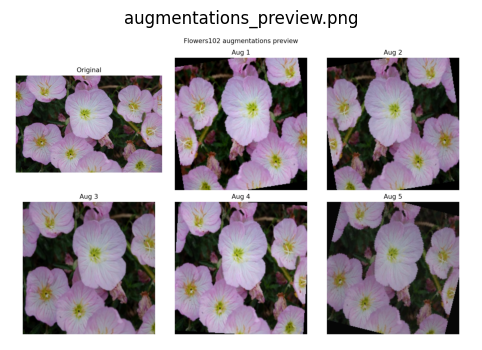

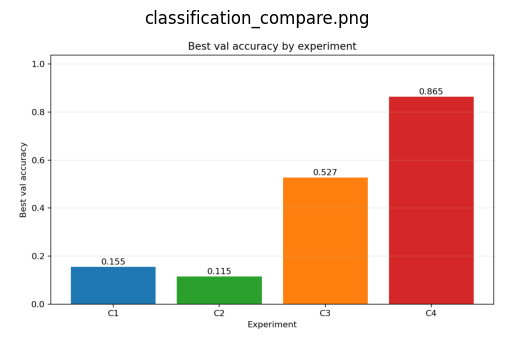

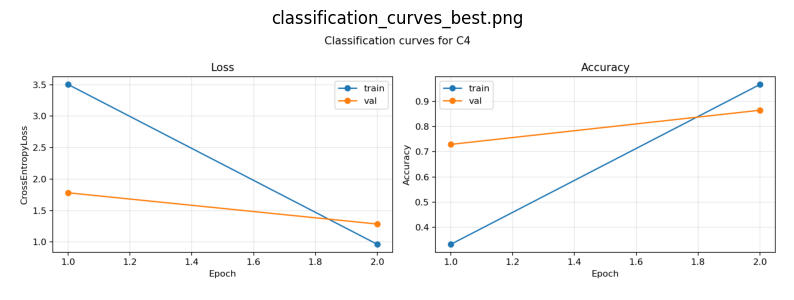

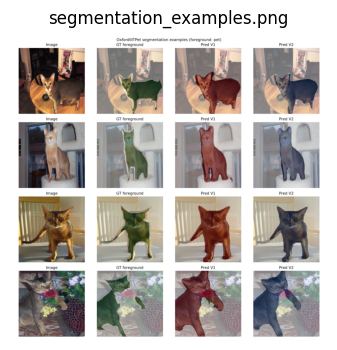

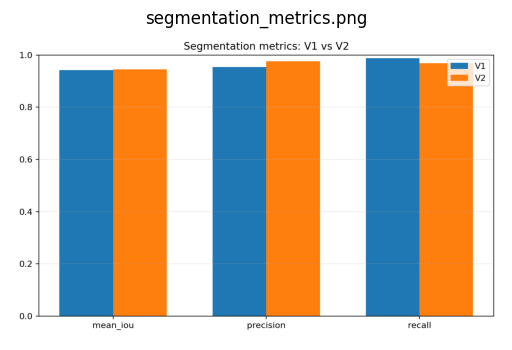

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
base = Path.cwd()
if not (base / 'artifacts').exists():
    base = Path('homeworks/HW10-11')
fig_paths = [
    base / 'artifacts' / 'figures' / 'augmentations_preview.png',
    base / 'artifacts' / 'figures' / 'classification_compare.png',
    base / 'artifacts' / 'figures' / 'classification_curves_best.png',
    base / 'artifacts' / 'figures' / 'segmentation_examples.png',
    base / 'artifacts' / 'figures' / 'segmentation_metrics.png',
]
for p in fig_paths:
    img = plt.imread(p)
    plt.figure(figsize=(10, 4))
    plt.imshow(img)
    plt.title(p.name)
    plt.axis('off')
    plt.show()